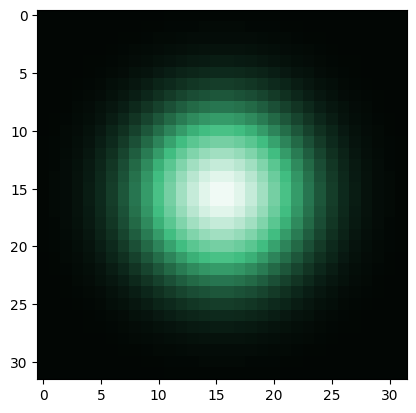

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pywt
import math
import wvltcc

from matplotlib.colors import LinearSegmentedColormap

colors = ['#FFCD00', '#0B8BEE', '#8F07AA', '#5BDEFF', '#D71131', '#35CA00', '#000']
map_colors = ['#020604', '#040c08', '#06120c', '#081811', '#0a1e15', '#0c2519',
              '#0e2b1d', '#113121', '#133725', '#153d29', '#17432e', '#194932',
              '#1b4f36', '#1d553a', '#1f5b3e', '#216142', '#236846', '#256e4a',
              '#27744f', '#297a53', '#2b8057', '#2e865b', '#308c5f', '#329263',
              '#349867', '#369e6c', '#38a470', '#3aab74', '#3cb178', '#3eb77c',
              '#40bd80', '#45c084', '#4bc288', '#51c48c', '#57c690', '#5ec894',
              '#64ca98', '#6acc9c', '#70cea0', '#76d0a4', '#7cd3a9', '#82d5ad',
              '#88d7b1', '#8ed9b5', '#94dbb9', '#9addbd', '#a1dfc1', '#a7e1c5',
              '#ade3c9', '#b3e5cd', '#b9e7d1', '#bfe9d5', '#c5ebd9', '#cbeddd',
              '#d1efe1', '#d7f2e5', '#ddf4e9', '#e4f6ed', '#eaf8f1', '#f0faf5',]
cmap = LinearSegmentedColormap.from_list('PhthaloGreen', map_colors, N=256)

# get filter bank of specified wavelet
tmp = pywt.Wavelet("bior6.8").filter_bank
dec_lo = np.asarray(tmp[0])
dec_hi = np.asarray(tmp[1])
rec_lo = np.asarray(tmp[2])
rec_hi = np.asarray(tmp[3])

# set size
size = 32

# define data
t = np.linspace(-1, 1, size)
x, y = np.meshgrid(t, t, indexing='ij')
cov_mat = np.array([[0.1, 0], [0, 0.1]])
mu = np.array([0, 0])
def data_fn(cord):
    data = 1 / (2 * np.pi * np.sqrt(np.linalg.det(cov_mat)))
    data *= np.exp(np.dot(-0.5 * (cord - mu).T, np.dot(np.linalg.inv(cov_mat), (cord - mu))))
    return data
data_fn_vec = np.vectorize(data_fn, signature='(n)->()')
data = data_fn_vec(np.array([x.ravel(), y.ravel()]).T).reshape((size, size))

plt.imshow(data, cmap=cmap)

## Run utils for recreating the error plots in the paper

In [ ]:
wvlt = ['db2', 'db3', 'db4']

for w in wvlt:
    # plot two-term residuals
    wvltcc.utils.plot_two_term_residuals(w, deriv_orders=np.arange(4), path='../figures', font_size=16)

    # plot three-term residuals
    x, y = np.meshgrid(np.arange(4), np.arange(4), indexing='ij')
    deriv_orders = np.vstack([x.ravel(), y.ravel()])
    wvltcc.utils.plot_three_term_residuals(w, deriv_orders=deriv_orders, path='../figures', font_size=16)

    # plot four-term residuals
    x, y, z = np.meshgrid(np.arange(4), np.arange(4), np.arange(4), indexing='ij')
    deriv_orders = np.vstack([x.ravel(), y.ravel(), z.ravel()])
    wvltcc.utils.plot_four_term_residuals(w, deriv_orders=deriv_orders, path='../figures', font_size=16)

## Time difference in computational speed between low-memory version and vectorized version

In [9]:
import time

wvlt = 'db4'
dt2s = []
dt3s = []
dt4s = []

# two-term solver timings
t0 = time.time()
tmp1 = wvltcc.coeffs.two_term_coeff_solver(wvlt, deriv_order=1, residuals=False)
t1 = time.time()
dt2s.append(t1 - t0)
t0 = time.time()
tmp2 = wvltcc.coeffs.two_term_coeff_solver_low_mem(wvlt, deriv_order=1, residuals=False)
t1 = time.time()
dt2s.append(t1 - t0)

# three-term solver timings
t0 = time.time()
tmp11 = wvltcc.coeffs.three_term_coeff_solver(wvlt, deriv_orders=np.array([1, 1]), residuals=False)
t1 = time.time()
dt3s.append(t1 - t0)
t0 = time.time()
tmp22 = wvltcc.coeffs.three_term_coeff_solver_low_mem(wvlt, deriv_orders=np.array([1, 1]), residuals=False)
t1 = time.time()
dt3s.append(t1 - t0)

# four-term solver timings
t0 = time.time()
tmp111 = wvltcc.coeffs.four_term_coeff_solver(wvlt, deriv_orders=np.array([1, 1, 1]), residuals=False)
t1 = time.time()
dt4s.append(t1 - t0)
t0 = time.time()
tmp222 = wvltcc.coeffs.four_term_coeff_solver_low_mem(wvlt, deriv_orders=np.array([1, 1, 1]), residuals=False)
t1 = time.time()
dt4s.append(t1 - t0)

print(f'Two-term solver times for {wvlt} wavelet (vectorized, low-mem):   ', dt2s)
print(f'Three-term solver times for {wvlt} wavelet (vectorized, low-mem): ', dt3s)
print(f'Four-term solver times for {wvlt} wavelet (vectorized, low-mem):  ', dt4s)

Two-term solver times for db4 wavelet (vectorized, low-mem):    [0.0018601417541503906, 0.0033893585205078125]
Three-term solver times for db4 wavelet (vectorized, low-mem):  [0.019342899322509766, 0.19408774375915527]
Four-term solver times for db4 wavelet (vectorized, low-mem):   [2.705773115158081, 20.71961283683777]


In [5]:
def two_term_coeff_solver(wvlt: str, deriv_orders: np.ndarray, residuals: bool = False) -> np.ndarray:

    # get filter bank of specified wavelet
    rec_lo = np.asarray(pywt.Wavelet(wvlt).filter_bank[2])

    # remove zeros from the reconstruction low-pass filter
    filt = rec_lo[rec_lo != 0]

    # set constants
    filt_len = len(filt)
    filt_idx = np.arange(-filt_len + 2, filt_len - 1)
    num_overlap = 2 * filt_len - 3

    # initialize the matrices for the eigenvalue problem
    two_term_ref = np.zeros((num_overlap, num_overlap))

    # populate the matrix from the refinement relations using a lookup table (more efficient)
    idx_lut = np.zeros(3 * num_overlap-1)
    for i in range(num_overlap+2):
        for n0 in range(filt_len):
            for n1 in range(filt_len):
                if (n0 - n1) == (i - filt_len + 1):
                    idx_lut[i + num_overlap - 1] += filt[n0] * filt[n1]
    for r in range(num_overlap):
        two_term_ref[r, :] = np.roll(idx_lut, 2 * r)[-num_overlap:]
        
    # populate the matrix from the refinement relations using nested loops (closely follows equations)
    # for l in range(num_overlap**2):
    #     r = l // num_overlap
    #     c = l % num_overlap
    #     k_in = c - filt_len + 2
    #     k_out = r - filt_len + 2
    #     for n0 in range(filt_len):
    #         for n1 in range(filt_len):
    #             if (n0 - n1) == (k_in - 2 * k_out):
    #                 two_term_ref[r, c] += filt[n0] * filt[n1]
    # build the least squares problem components of the refinement relation
    two_term_ref_mat = two_term_ref - (1 / 2 ** deriv_orders[0]) * np.eye(num_overlap)
    two_term_ref_rhs = np.zeros(num_overlap)

    # build the least squares problem components of the moment equation
    two_term_mom_lhs = np.empty((1, num_overlap))
    two_term_mom_lhs[0, :] = filt_idx**deriv_orders[0]
    two_term_mom_rhs = np.empty(1)
    two_term_mom_rhs[0] = math.factorial(deriv_orders[0]) #* (-1)**deriv_orders[0]

    # build the least squares problem
    lhs = np.vstack((two_term_ref_mat, two_term_mom_lhs))
    rhs = np.concatenate((two_term_ref_rhs, two_term_mom_rhs))

    # solve least squares approximation (numpy uses SVD under the hood)
    two_term_coeff, res, rank, s = np.linalg.lstsq(lhs, rhs, rcond=None)

    if residuals:
        # check residuals for refinement and moment equations
        ref_error = np.linalg.norm(np.dot(two_term_ref, two_term_coeff) - 1/2**deriv_orders[0] * two_term_coeff)
        mom_error = np.linalg.norm(np.dot(two_term_mom_lhs, two_term_coeff) - two_term_mom_rhs)
        
        return two_term_coeff, ref_error, mom_error
    
    return two_term_coeff

In [4]:
ref_list = []
mom_list = []
coeffs_list = []

for i in range(6):
    coeffs, ref, mom = two_term_coeff_solver('db3', np.array([i]), True)
    ref_list.append(ref)
    mom_list.append(mom)
    coeffs_list.append(coeffs)
    print(f"Order {i}: Refinment Residual = {ref}, Moment Residual = {mom}")

Order 0: Refinment Residual = 5.717764594251869e-16, Moment Residual = 4.440892098500626e-16
Order 1: Refinment Residual = 6.077741309098195e-16, Moment Residual = 8.881784197001252e-16
Order 2: Refinment Residual = 2.2044832983453592e-15, Moment Residual = 1.7763568394002505e-15
Order 3: Refinment Residual = 1.0352511154691271e-15, Moment Residual = 1.7763568394002505e-15
Order 4: Refinment Residual = 1.022403166495331e-14, Moment Residual = 3.197442310920451e-14
Order 5: Refinment Residual = 1.0513306385628922e-14, Moment Residual = 0.0


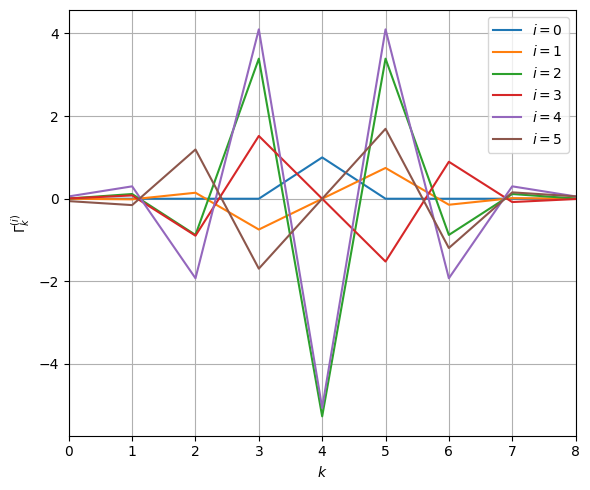

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
for i in range(6):
    ax.plot(coeffs_list[i], label=rf'$i = {i}$')
ax.legend()
ax.grid()
ax.set_xlim(0, 8)
ax.set_xlabel(r'$k$')
ax.set_ylabel(r'$\Gamma_{k}^{(i)}$')
fig.tight_layout()
#fig.savefig('../figures/two_term_db3_coeffs.pdf', dpi=100)

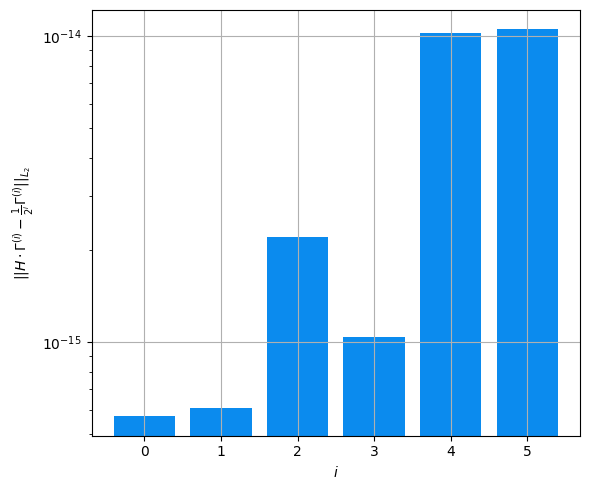

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
for i in range(6):
    ax.bar(i, ref_list[i], label=rf'$i = {i}$', color=colors[1])
ax.set_yscale('log')
ax.set_xlabel(r'$i$')
ax.set_ylabel(r'$|| H \cdot \Gamma^{(i)} - \frac{1}{2^i} \Gamma^{(i)} ||_{L_2}$')
ax.grid()
fig.tight_layout()
#fig.savefig('../figures/two_term_db3_refinement_residuals.pdf', dpi=100)

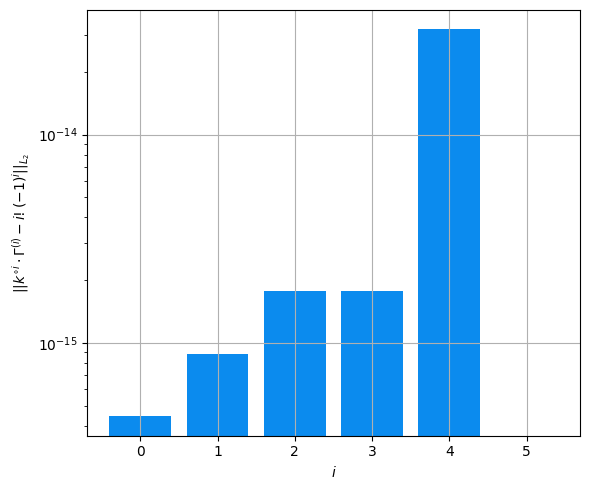

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
for i in range(6):
    ax.bar(i, mom_list[i], label=rf'$i = {i}$', color=colors[1])
ax.set_yscale('log')
ax.set_xlabel(r'$i$')
ax.set_ylabel(r'$|| k^{\circ i} \cdot \Gamma^{(i)} - i! ||_{L_2}$')
ax.grid()
fig.tight_layout()
#fig.savefig('../figures/two_term_db3_momentum_residuals.pdf', dpi=100)

In [4]:
def three_term_coeff_solver(wvlt: str, deriv_orders: np.ndarray, residuals: bool = False) -> np.ndarray:
    # wvlt = 'db3'
    # deriv_orders = np.array([1, 1])
    # residuals = True

    # get filter bank of specified wavelet
    rec_lo = np.asarray(pywt.Wavelet(wvlt).filter_bank[2])

    # remove zeros from the reconstruction low-pass  
    filt = rec_lo[rec_lo != 0]

    # set constants
    filt_len = len(filt)
    filt_idx = np.arange(-filt_len + 2, filt_len - 1)
    num_nonzero_coeffs = 2 * filt_len - 3

    # get the order of derivation for each term
    i1 = deriv_orders[0]
    i2 = deriv_orders[1]

    # compute two-term coefficients for each derivation order
    two_term_i1 = two_term_coeff_solver(wvlt, np.array([i1]))
    two_term_i2 = two_term_coeff_solver(wvlt, np.array([i2]))

    def map_indices(j, k):
        idx = (j + filt_len - 2) * num_nonzero_coeffs + (k + filt_len - 2)
        return idx

    # populate the block matrix from refinement relations
    three_term_ref = np.zeros((num_nonzero_coeffs**2, num_nonzero_coeffs**2))
    for k1_out in filt_idx:
        for k2_out in filt_idx:
            r = map_indices(k1_out, k2_out)
            for n0 in range(filt_len):
                for n1 in range(filt_len):
                    for n2 in range(filt_len):
                        k1_in = 2 * k1_out + n1 - n0
                        k2_in = 2 * k2_out + n2 - n0
                        if np.abs(k1_in) < filt_len - 1 and np.abs(k2_in) < filt_len - 1:
                            c = map_indices(k1_in, k2_in)
                            three_term_ref[r, c] += filt[n0] * filt[n1] * filt[n2]

    # populate the block matrix from the moment equations
    three_term_mom_mat = np.zeros((2 * num_nonzero_coeffs, num_nonzero_coeffs**2))
    three_term_mom_rhs = np.zeros(2 * num_nonzero_coeffs)

    # moment equation for m
    for i, k1_phys in enumerate(filt_idx):
        for k2_phys in filt_idx:
            col_idx = map_indices(k1_phys, k2_phys)
            three_term_mom_mat[i, col_idx] = k2_phys**i2
        three_term_mom_rhs[i] = math.factorial(i2) * two_term_i1[i]

    # moment equation for n
    for i, k2_phys in enumerate(filt_idx):
        for k1_phys in filt_idx:
            col_idx = map_indices(k1_phys, k2_phys)
            three_term_mom_mat[i + num_nonzero_coeffs, col_idx] = k1_phys**i1
        three_term_mom_rhs[i + num_nonzero_coeffs] = math.factorial(i1) * two_term_i2[i]

    # target eigenvalue
    target_lambda = 1 / 2**(i1 + i2 + 0.5)

    # construct eigenvalue problem
    three_term_ref_mat = three_term_ref - target_lambda * np.eye(num_nonzero_coeffs**2)
    three_term_ref_rhs = np.zeros(num_nonzero_coeffs**2)

    # build the least squares problem
    lhs = np.vstack((three_term_ref_mat, three_term_mom_mat))
    rhs = np.concatenate((three_term_ref_rhs, three_term_mom_rhs))

    # solve least squares approximation
    three_term_coeff, res, rank, s = np.linalg.lstsq(lhs, rhs, rcond=None)

    if residuals:
        # check residuals for refinement and moment equations
        ref_error = np.linalg.norm(np.dot(three_term_ref, three_term_coeff) - target_lambda * three_term_coeff)
        mom_error = np.linalg.norm(np.dot(three_term_mom_mat, three_term_coeff) - three_term_mom_rhs)
        
        three_term_coeff, ref_error, mom_error
        
    return three_term_coeff

In [4]:
test = wvltcc.coeffs.three_term_coeff_solver('db3', np.array([1, 1]), True)

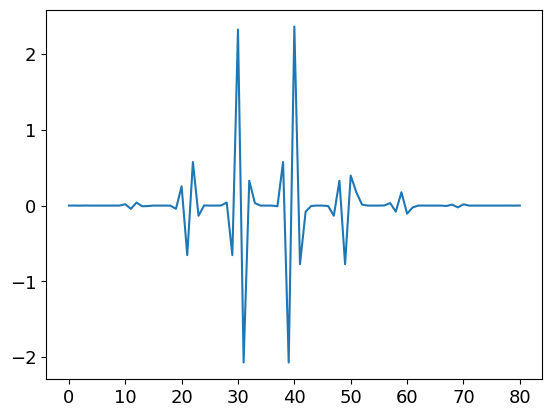

In [5]:
plt.plot(test[0])

In [2]:
wvlt = 'db3'
deriv_orders = np.array([1])
residuals = True

# get filter bank of specified wavelet
rec_lo = np.asarray(pywt.Wavelet(wvlt).filter_bank[2])

# remove zeros from the reconstruction low-pass filter
filt = rec_lo[rec_lo != 0]

# set constants
filt_len = len(filt)
filt_idx = np.arange(-filt_len + 2, filt_len - 1)
num_overlap = 2 * filt_len - 3

# initialize the matrices for the eigenvalue problem
two_term_ref = np.zeros((num_overlap, num_overlap))

# populate the matrix from the refinement relations using a lookup table (more efficient)
idx_lut = np.zeros(3 * num_overlap-1)
for i in range(num_overlap+2):
    for n0 in range(filt_len):
        for n1 in range(filt_len):
            if (n0 - n1) == (i - filt_len + 1):
                idx_lut[i + num_overlap - 1] += filt[n0] * filt[n1]
for r in range(num_overlap):
    two_term_ref[r, :] = np.roll(idx_lut, 2 * r)[-num_overlap:]

In [6]:
wvlt = 'db3'
deriv_orders = np.array([1, 1])
residuals = True

# get filter bank of specified wavelet
rec_lo = np.asarray(pywt.Wavelet(wvlt).filter_bank[2])

# remove zeros from the reconstruction low-pass  
filt = rec_lo[rec_lo != 0]

# set constants
filt_len = len(filt)
filt_idx = np.arange(-filt_len + 2, filt_len - 1)
num_nonzero_coeffs = 2 * filt_len - 3

# get the order of derivation for each term
i1 = deriv_orders[0]
i2 = deriv_orders[1]

# compute two-term coefficients for each derivation order
two_term_i1 = two_term_coeff_solver(wvlt, np.array([i1]))
two_term_i2 = two_term_coeff_solver(wvlt, np.array([i2]))

def map_indices(j, k):
    idx = (j + filt_len - 2) * num_nonzero_coeffs + (k + filt_len - 2)
    return idx

# populate the block matrix from refinement relations
three_term_ref = np.zeros((num_nonzero_coeffs**2, num_nonzero_coeffs**2))
for k1_out in filt_idx:
    for k2_out in filt_idx:
        r = map_indices(k1_out, k2_out)
        for n0 in range(filt_len):
            for n1 in range(filt_len):
                for n2 in range(filt_len):
                    k1_in = 2 * k1_out + n1 - n0
                    k2_in = 2 * k2_out + n2 - n0
                    if np.abs(k1_in) < filt_len - 1 and np.abs(k2_in) < filt_len - 1:
                        c = map_indices(k1_in, k2_in)
                        three_term_ref[r, c] += filt[n0] * filt[n1] * filt[n2]

In [7]:
# def four_term_coeff_solver(wvlt: str, deriv_orders: np.ndarray, residuals: bool = False) -> np.ndarray:
wvlt = 'db3'
deriv_orders = np.array([0, 1, 0])
residuals = True

# get filter bank of specified wavelet
rec_lo = np.asarray(pywt.Wavelet(wvlt).filter_bank[2])

# remove zeros from the reconstruction low-pass  
filt = rec_lo[rec_lo != 0]

# set constants
filt_len = len(filt)
filt_idx = np.arange(-filt_len + 2, filt_len - 1)
num_nonzero_coeffs = 2 * filt_len - 3

# get the order of derivation for each term
i1 = deriv_orders[0]
i2 = deriv_orders[1]
i3 = deriv_orders[2]

# compute three-term coefficients for each derivation order
three_term_i1i2 = three_term_coeff_solver(wvlt, np.array([i1, i2]))
three_term_i1i3 = three_term_coeff_solver(wvlt, np.array([i1, i3]))
three_term_i2i3 = three_term_coeff_solver(wvlt, np.array([i2, i3]))

def map_indices(i, j, k):
    idx = (i + filt_len - 2) * num_nonzero_coeffs**2 + (j + filt_len - 2) * num_nonzero_coeffs + (k + filt_len - 2)
    return idx

# populate the block matrix from refinement relations
four_term_ref = np.zeros((num_nonzero_coeffs**3, num_nonzero_coeffs**3))
for k1_out in filt_idx:
    for k2_out in filt_idx:
        for k3_out in filt_idx:
            r = map_indices(k1_out, k2_out, k3_out)
            for n0 in range(filt_len):
                for n1 in range(filt_len):
                    for n2 in range(filt_len):
                        for n3 in range(filt_len):
                            k1_in = 2 * k1_out + n1 - n0
                            k2_in = 2 * k2_out + n2 - n0
                            k3_in = 2 * k3_out + n3 - n0
                            if np.abs(k1_in) < filt_len - 1 and np.abs(k2_in) < filt_len - 1 and np.abs(k3_in) < filt_len - 1:
                                c = map_indices(k1_in, k2_in, k3_in)
                                four_term_ref[r, c] += filt[n0] * filt[n1] * filt[n2] * filt[n3]

# populate the block matrix from the moment equations
four_term_mom_mat = np.zeros((3 * num_nonzero_coeffs**2, num_nonzero_coeffs**3))
four_term_mom_rhs = np.zeros(3 * num_nonzero_coeffs**2)

# moment equation for i3
i = 0
for k1_phys in filt_idx:
    for k2_phys in filt_idx:
        for k3_phys in filt_idx:
            col_idx = map_indices(k1_phys, k2_phys, k3_phys)
            four_term_mom_mat[i, col_idx] = k3_phys**i3
        four_term_mom_rhs[i] = math.factorial(i3) * three_term_i1i2[i]
        i += 1

# moment equation for i2
i = 0
for k1_phys in filt_idx:
    for k3_phys in filt_idx:
        for k2_phys in filt_idx:
            col_idx = map_indices(k1_phys, k2_phys, k3_phys)
            four_term_mom_mat[i + num_nonzero_coeffs**2, col_idx] = k2_phys**i2
        four_term_mom_rhs[i + num_nonzero_coeffs**2] = math.factorial(i2) * three_term_i1i3[i]
        i += 1

# moment equation for i1
i = 0
for k2_phys in filt_idx:
    for k3_phys in filt_idx:
        for k1_phys in filt_idx:
            col_idx = map_indices(k1_phys, k2_phys, k3_phys)
            four_term_mom_mat[i + 2 * num_nonzero_coeffs**2, col_idx] = k1_phys**i1
        four_term_mom_rhs[i + 2 * num_nonzero_coeffs**2] = math.factorial(i1) * three_term_i2i3[i]
        i += 1

# target eigenvalue
target_lambda = 1 / 2**(i1 + i2 + i3 + 1)

# construct eigenvalue problem
four_term_ref_mat = four_term_ref - target_lambda * np.eye(num_nonzero_coeffs**3)
four_term_ref_rhs = np.zeros(num_nonzero_coeffs**3)

# build the least squares problem
lhs = np.vstack((four_term_ref_mat, four_term_mom_mat))
rhs = np.concatenate((four_term_ref_rhs, four_term_mom_rhs))

# solve least squares approximation
four_term_coeff, res, rank, s = np.linalg.lstsq(lhs, rhs, rcond=None)

if residuals:
    # check residuals for refinement and moment equations
    ref_error = np.linalg.norm(np.dot(four_term_ref, four_term_coeff) - target_lambda * four_term_coeff)
    mom_error = np.linalg.norm(np.dot(four_term_mom_mat, four_term_coeff) - four_term_mom_rhs)
    
    four_term_coeff, ref_error, mom_error
    
    # return four_term_coeff

In [25]:
ref_error, mom_error

(np.float64(1.7880668803903237e-15), np.float64(2.807387234637919e-15))

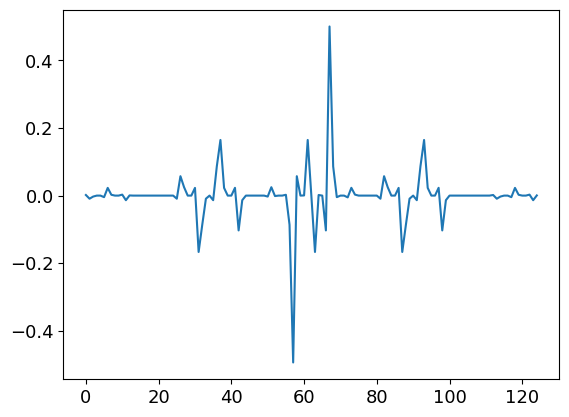

In [26]:
plt.plot(four_term_coeff)

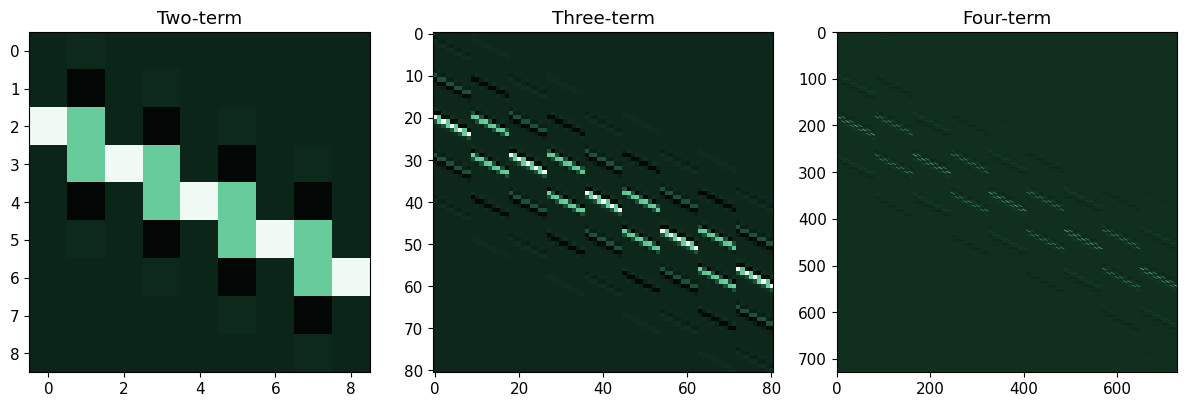

In [10]:
from matplotlib import rcParams
rcParams.update({'font.size': 11})

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(two_term_ref, cmap=cmap)
ax[0].set_title('Two-term')
ax[1].imshow(three_term_ref, cmap=cmap)
ax[1].set_title('Three-term')
ax[2].imshow(four_term_ref, cmap=cmap)
ax[2].set_title('Four-term')
fig.tight_layout()
fig.savefig('../figures/refinement_matrices_db3.pdf', dpi=200)

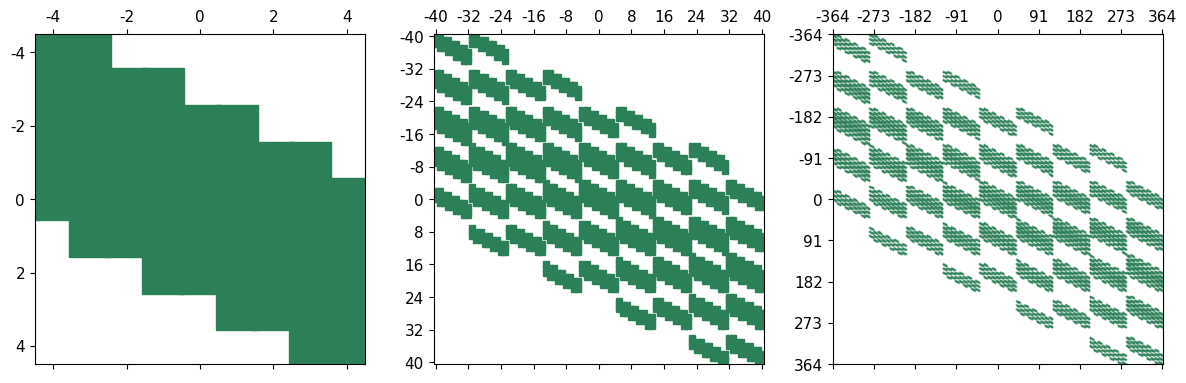

In [49]:
from matplotlib import rcParams
rcParams.update({'font.size': 11})

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].spy(two_term_ref, markersize=30, color="#2b8057")
ax[0].set_xticks(np.arange(0, two_term_ref.shape[0], 2))
ax[0].set_yticks(np.arange(0, two_term_ref.shape[0], 2))
ax[0].set_xticklabels(np.arange(-4, 5, 2))
ax[0].set_yticklabels(np.arange(-4, 5, 2))
ax[0].set_aspect('equal')
ax[1].spy(three_term_ref, markersize=4, color="#2b8057")
ax[1].set_xticks(np.arange(0, three_term_ref.shape[0], 8))
ax[1].set_yticks(np.arange(0, three_term_ref.shape[0], 8))
ax[1].set_xticklabels(np.arange(-40, 41, 8))
ax[1].set_yticklabels(np.arange(-40, 41, 8))
ax[1].set_aspect('equal')
ax[2].spy(four_term_ref, markersize=0.1, color="#2b8057")
ax[2].set_xticks(np.arange(0, four_term_ref.shape[0], 91))
ax[2].set_yticks(np.arange(0, four_term_ref.shape[0], 91))
ax[2].set_xticklabels(np.arange(-364, 365, 91))
ax[2].set_yticklabels(np.arange(-364, 365, 91))
ax[2].set_aspect('equal')
fig.tight_layout()
fig.savefig('../figures/refinement_matrices_db3_pop.pdf', dpi=200)